In [3]:
import os
import numpy as np
import pandas as pd

# ============================================================
# ======================= USER INPUTS =========================
# ============================================================

# ---- Path to aligned_frames.npy (from your TTL repair tool) ----
aligned_frames_path = r"D:\Kevin\04032026\04032026-1\cam1\aligned_frames.npy"

# ---- Path to DeepLabCut output (CSV or H5) ----
dlc_output_path = r"F:\Mouse1_030426-Kpk\videos\04032026-1_cam1DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100.h5"

# ---- Output folder for dlc_aligned.npy ----
output_folder = r"D:\Kevin\04032026\04032026-1\cam1"


# ============================================================
# ======================= LOAD DATA ===========================
# ============================================================

# Load aligned_frames (TTL-aligned raw frame filenames)
aligned_frames = np.load(aligned_frames_path, allow_pickle=True)
TTL_COUNT = len(aligned_frames)
print(f"Loaded aligned_frames with length {TTL_COUNT}")

# Load DLC output (CSV or H5)
if dlc_output_path.endswith(".csv"):
    df_dlc = pd.read_csv(dlc_output_path)
elif dlc_output_path.endswith(".h5") or dlc_output_path.endswith(".hdf5"):
    df_dlc = pd.read_hdf(dlc_output_path)
else:
    raise ValueError("DLC output must be .csv or .h5")

print(f"Loaded DLC output with {len(df_dlc)} frames")


# ============================================================
# ========== MAP DLC ROWS TO RAW FRAME INDICES ===============
# ============================================================

# DLC frame index corresponds to raw frame index IF video was built sequentially
# So DLC row i corresponds to raw frame index i
dlc_by_raw_index = {i: df_dlc.iloc[i] for i in range(len(df_dlc))}


# ============================================================
# ========== BUILD TTL-ALIGNED DLC TIMELINE ==================
# ============================================================

dlc_aligned = []

for f in aligned_frames:
    if f is None:
        dlc_aligned.append(None)
    else:
        # Extract raw frame index from filename: frame_000123_cnt_XXXXXX.raw
        raw_idx = int(f.split("_")[1])
        dlc_aligned.append(dlc_by_raw_index.get(raw_idx, None))

dlc_aligned = np.array(dlc_aligned, dtype=object)

print("Built dlc_aligned timeline.")
print(f"Length: {len(dlc_aligned)}")
print(f"Missing DLC entries: {sum(x is None for x in dlc_aligned)}")


# ============================================================
# ======================= SAVE OUTPUT =========================
# ============================================================

output_path = os.path.join(output_folder, "dlc_aligned.npy")
np.save(output_path, dlc_aligned)

print(f"\nSaved dlc_aligned.npy to:\n{output_path}")

Loaded aligned_frames with length 134516
Loaded DLC output with 120268 frames
Built dlc_aligned timeline.
Length: 134516
Missing DLC entries: 14248

Saved dlc_aligned.npy to:
D:\Kevin\04032026\04032026-1\cam1\dlc_aligned.npy


Loaded DLC-aligned timeline: 134516
Loaded DLC dataframe: (120268, 15)
Columns for bodypart: [('DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100', 'paw', 'x'), ('DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100', 'paw', 'y'), ('DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100', 'paw', 'likelihood')]


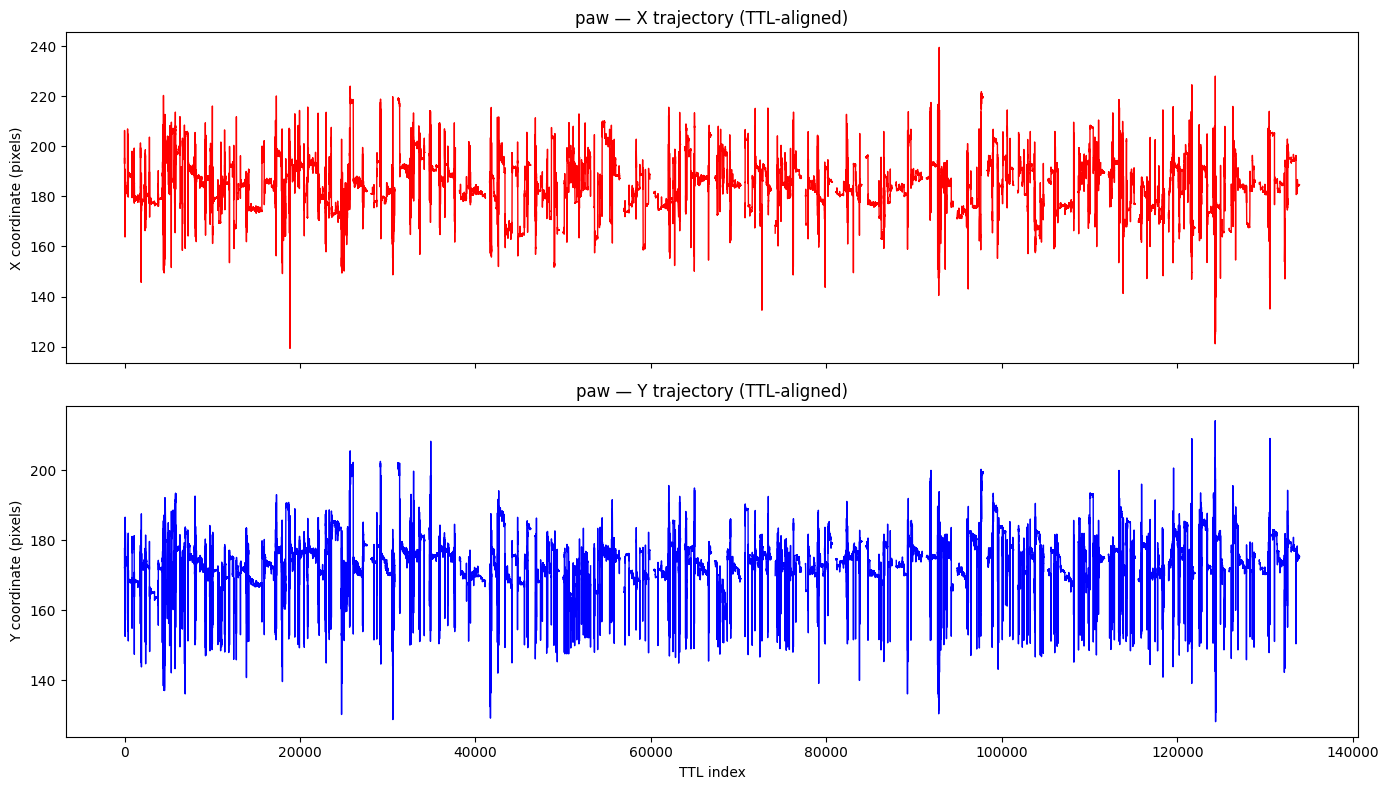

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ======================= USER INPUTS =========================
# ============================================================

# Path to dlc_aligned.npy
dlc_aligned_path = r"D:\Kevin\04032026\04032026-1\cam1\dlc_aligned.npy" ###########################################################################################################################

# Path to original DLC .h5 file (needed to get column structure)
dlc_h5_path = r"F:\Mouse1_030426-Kpk\videos\04032026-1_cam1DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100.h5"   ########################################################################

# Body part to plot (must match DLC labels)
bodypart = "paw"   #################################################################################################################################################################################


# ============================================================
# ======================= LOAD DATA ===========================
# ============================================================

# Load DLC-aligned timeline (length = TTL_COUNT)
dlc_aligned = np.load(dlc_aligned_path, allow_pickle=True)

# Load original DLC dataframe to inspect column structure
df_dlc = pd.read_hdf(dlc_h5_path)

print("Loaded DLC-aligned timeline:", len(dlc_aligned))
print("Loaded DLC dataframe:", df_dlc.shape)


# ============================================================
# ========== EXTRACT BODY PART COLUMNS FROM DLC ==============
# ============================================================

# DLC uses a MultiIndex: (scorer, bodypart, coordinate)
# Example: ('DLC_resnet50', 'paw', 'x')

# Find all columns for this bodypart
cols = [col for col in df_dlc.columns if col[1] == bodypart]

if len(cols) == 0:
    raise ValueError(f"Bodypart '{bodypart}' not found in DLC file. Available: {set(c[1] for c in df_dlc.columns)}")

print("Columns for bodypart:", cols)

# Coordinates
x_col = [c for c in cols if c[2] == 'x'][0]
y_col = [c for c in cols if c[2] == 'y'][0]
lik_col = [c for c in cols if c[2] == 'likelihood'][0]


# ============================================================
# ========== BUILD TTL-ALIGNED X/Y TRAJECTORIES ==============
# ============================================================

x_aligned = []
y_aligned = []
lik_aligned = []

for row in dlc_aligned:
    if row is None:
        x_aligned.append(np.nan)
        y_aligned.append(np.nan)
        lik_aligned.append(np.nan)
    else:
        x_aligned.append(row[x_col])
        y_aligned.append(row[y_col])
        lik_aligned.append(row[lik_col])

x_aligned = np.array(x_aligned, dtype=float)
y_aligned = np.array(y_aligned, dtype=float)
lik_aligned = np.array(lik_aligned, dtype=float)


# ============================================================
# ======================= PLOT RESULTS ========================
# ============================================================

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(x_aligned, color='red', linewidth=1)
ax[0].set_ylabel("X coordinate (pixels)")
ax[0].set_title(f"{bodypart} — X trajectory (TTL-aligned)")

ax[1].plot(y_aligned, color='blue', linewidth=1)
ax[1].set_ylabel("Y coordinate (pixels)")
ax[1].set_xlabel("TTL index")
ax[1].set_title(f"{bodypart} — Y trajectory (TTL-aligned)")

plt.tight_layout()
plt.show()

Total frames: 134516
Frames above likelihood threshold: 4913
Frames removed: 129603


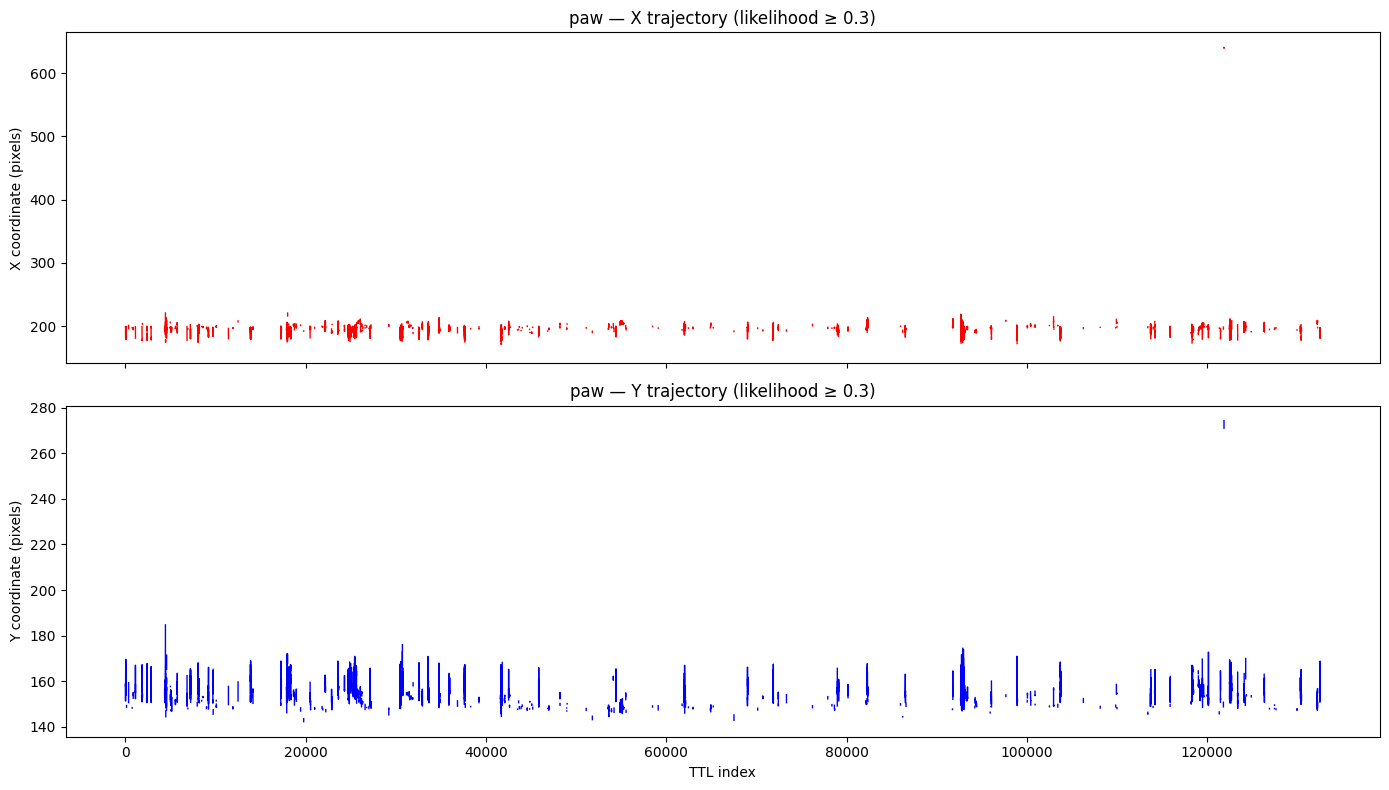

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ======================= USER INPUTS =========================
# ============================================================

lik_threshold = 0.3   ############################################################
bodypart_name = "paw" ############################################################


# ============================================================
# ======================= FILTER DATA =========================
# ============================================================

# Convert to numpy arrays if not already
x = np.array(x_aligned, dtype=float)
y = np.array(y_aligned, dtype=float)
lik = np.array(lik_aligned, dtype=float)

# Mask: True where likelihood is high enough
mask = lik >= lik_threshold

# Apply mask: low-likelihood values become NaN
x_filt = np.where(mask, x, np.nan)
y_filt = np.where(mask, y, np.nan)

print(f"Total frames: {len(x)}")
print(f"Frames above likelihood threshold: {np.sum(mask)}")
print(f"Frames removed: {np.sum(~mask)}")


# ============================================================
# ======================= PLOT RESULTS ========================
# ============================================================

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(x_filt, color='red', linewidth=1)
ax[0].set_ylabel("X coordinate (pixels)")
ax[0].set_title(f"{bodypart_name} — X trajectory (likelihood ≥ {lik_threshold})")

ax[1].plot(y_filt, color='blue', linewidth=1)
ax[1].set_ylabel("Y coordinate (pixels)")
ax[1].set_xlabel("TTL index")
ax[1].set_title(f"{bodypart_name} — Y trajectory (likelihood ≥ {lik_threshold})")

plt.tight_layout()
plt.show()

Detected 57 peaks above threshold 180
TTL   2862 | Frame   2862 | Y = 185.48
TTL   3870 | Frame   3870 | Y = 186.33
TTL   4435 | Frame   4435 | Y = 184.74
TTL   4738 | Frame   4738 | Y = 215.44
TTL   6973 | Frame   6973 | Y = 191.00
TTL   8171 | Frame   8171 | Y = 184.64
TTL  13257 | Frame  13257 | Y = 187.06
TTL  13943 | Frame  13943 | Y = 184.01
TTL  15680 | Frame  15680 | Y = 190.08
TTL  22864 | Frame  22864 | Y = 187.72
TTL  22936 | Frame  22936 | Y = 191.67
TTL  25696 | Frame  25696 | Y = 186.77
TTL  29178 | Frame  28684 | Y = 186.96
TTL  36512 | Frame  35151 | Y = 183.33
TTL  41756 | Frame  39451 | Y = 181.28
TTL  42603 | Frame  40298 | Y = 188.28
TTL  49056 | Frame  46284 | Y = 190.80
TTL  53536 | Frame  49905 | Y = 182.73
TTL  54391 | Frame  50760 | Y = 187.07
TTL  55730 | Frame  52099 | Y = 190.76
TTL  61485 | Frame  56900 | Y = 184.80
TTL  61968 | Frame  57383 | Y = 181.64
TTL  69140 | Frame  63700 | Y = 189.65
TTL  73311 | Frame  67396 | Y = 184.18
TTL  77906 | Frame  71057 

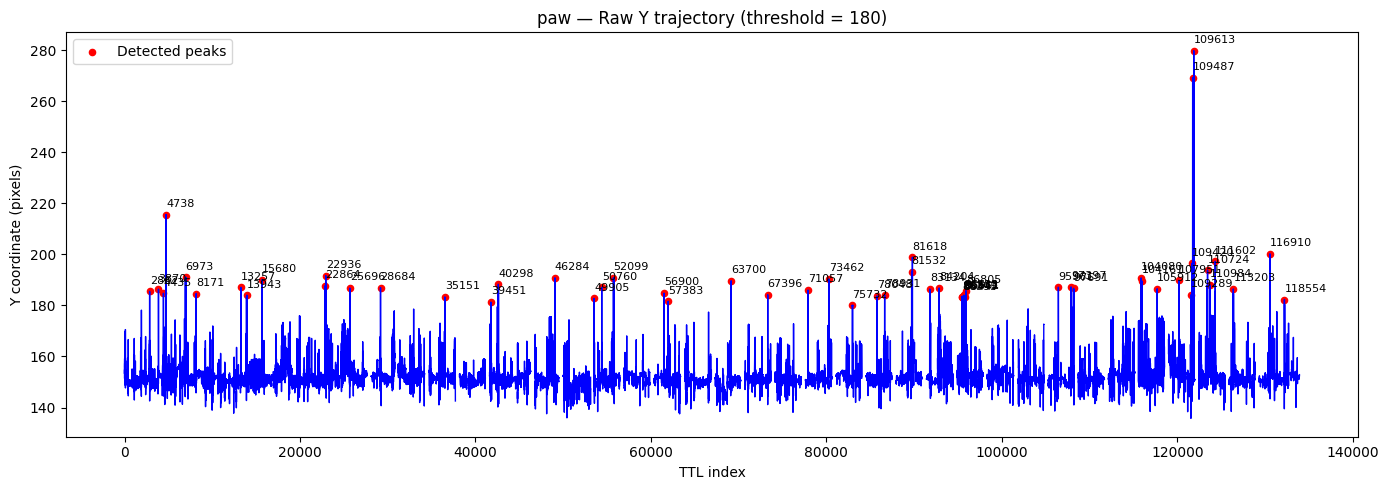

In [15]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# ============================================================
# ======================= USER INPUTS =========================
# ============================================================

threshold = 180   ############################################################
min_peak_distance = 50   #####################################################
bodypart_name = "paw"    #####################################################


# ============================================================
# ======================= RAW DATA ============================
# ============================================================

# y_aligned must already exist (TTL-aligned Y trajectory)
# aligned_frames must already exist (TTL-aligned filenames)

y = np.array(y_aligned, dtype=float)


# ============================================================
# ======================= FIND PEAKS ==========================
# ============================================================

peaks, props = find_peaks(
    y,
    height=threshold,
    distance=min_peak_distance
)

print(f"Detected {len(peaks)} peaks above threshold {threshold}")


# ============================================================
# ======================= PRINT RESULTS =======================
# ============================================================

results = []

for ttl_idx in peaks:
    filename = aligned_frames[ttl_idx]
    if filename is None:
        raw_idx = None
    else:
        raw_idx = int(filename.split("_")[1])

    peak_y = y[ttl_idx]

    results.append((ttl_idx, raw_idx, peak_y))

# Print in readable format
for ttl_idx, raw_idx, peak_y in results:
    print(f"TTL {ttl_idx:6d} | Frame {raw_idx:6d} | Y = {peak_y:.2f}")


# ============================================================
# ======================= OPTIONAL PLOT =======================
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y, color='blue', linewidth=1)
ax.scatter(peaks, y[peaks], color='red', s=20, label="Detected peaks")

# Annotate with frame numbers
for ttl_idx, raw_idx, peak_y in results:
    if raw_idx is not None:
        ax.text(ttl_idx, peak_y + 3, str(raw_idx), fontsize=8, color='black')

ax.set_title(f"{bodypart_name} — Raw Y trajectory (threshold = {threshold})")
ax.set_xlabel("TTL index")
ax.set_ylabel("Y coordinate (pixels)")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd

# ================= USER INPUTS =================
target_raw_idx = 109613   #####################################################
bodypart = "paw"          #####################################################
aligned_frames_path = r"D:\Kevin\04032026\04032026-1\cam1\aligned_frames.npy" ###########################
dlc_h5_path = r"F:\Mouse1_030426-Kpk\videos\04032026-1_cam1DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100.h5" ##############################################

# ================ LOAD DATA ====================
aligned_frames = np.load(aligned_frames_path, allow_pickle=True)
df_dlc = pd.read_hdf(dlc_h5_path)

# DLC columns for this bodypart
cols = [col for col in df_dlc.columns if col[1] == bodypart]
x_col = [c for c in cols if c[2] == 'x'][0]
y_col = [c for c in cols if c[2] == 'y'][0]
lik_col = [c for c in cols if c[2] == 'likelihood'][0]

print("DLC row for raw frame index", target_raw_idx)
print("x:", df_dlc.loc[target_raw_idx, x_col])
print("y:", df_dlc.loc[target_raw_idx, y_col])
print("lik:", df_dlc.loc[target_raw_idx, lik_col])

# ============ FIND TTL INDEX(ES) FOR THIS FRAME ============
ttl_indices = [
    i for i, f in enumerate(aligned_frames)
    if f is not None and int(f.split("_")[1]) == target_raw_idx
]

print("\nTTL indices that map to raw frame", target_raw_idx, ":", ttl_indices)

DLC row for raw frame index 109613
x: 167.74046
y: 170.51762
lik: 0.9988394

TTL indices that map to raw frame 109613 : [121868]


In [17]:
window = 5  # look at a few neighbors
start = max(0, ttl_idx - window)
end = ttl_idx + window + 1

print("\nTTL indices:", list(range(start, end)))
print("Y values:", y_aligned[start:end])
print("Likelihoods:", lik_aligned[start:end])
print("Frame indices:", [
    None if aligned_frames[i] is None else int(aligned_frames[i].split("_")[1])
    for i in range(start, end)
])


TTL indices: [132197, 132198, 132199, 132200, 132201, 132202, 132203, 132204, 132205, 132206, 132207]
Y values: [149.27508545 144.60525513 148.18873596 149.34695435 155.34393311
 182.30226135 150.60610962 150.09092712 150.12834167 150.52989197
 154.62532043]
Likelihoods: [0.22134547 0.11468967 0.15795019 0.13424781 0.12456477 0.10757933
 0.13041438 0.19055568 0.24367481 0.19557187 0.18088074]
Frame indices: [118549, 118550, 118551, 118552, 118553, 118554, 118555, 118556, 118557, 118558, 118559]


In [18]:
ttl_idx = 121868
filename = aligned_frames[ttl_idx]
raw_idx = int(filename.split("_")[1])
print("TTL index:", ttl_idx, "→ raw frame:", raw_idx)

# Compare DLC Y at that raw frame vs Y plotted at TTL index
print("DLC Y at raw frame:", df_dlc.loc[raw_idx, y_col])
print("Y plotted at TTL index:", y_aligned[ttl_idx])

TTL index: 121868 → raw frame: 109613
DLC Y at raw frame: 170.51762
Y plotted at TTL index: 279.7382507324219


In [19]:
import numpy as np

target_y = 279.7382507324219   # your spike value
tol = 1e-3                     # tolerance for float comparison

# Find all DLC rows where Y is close to the spike value
matches = np.where(np.abs(df_dlc[y_col].values - target_y) < tol)[0]

print("DLC rows with Y ≈", target_y, ":", matches)

DLC rows with Y ≈ 279.7382507324219 : []


Loaded DLC-aligned timeline: 134516
Loaded DLC dataframe: (120268, 15)
Columns for bodypart: [('DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100', 'tongue', 'x'), ('DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100', 'tongue', 'y'), ('DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100', 'tongue', 'likelihood')]


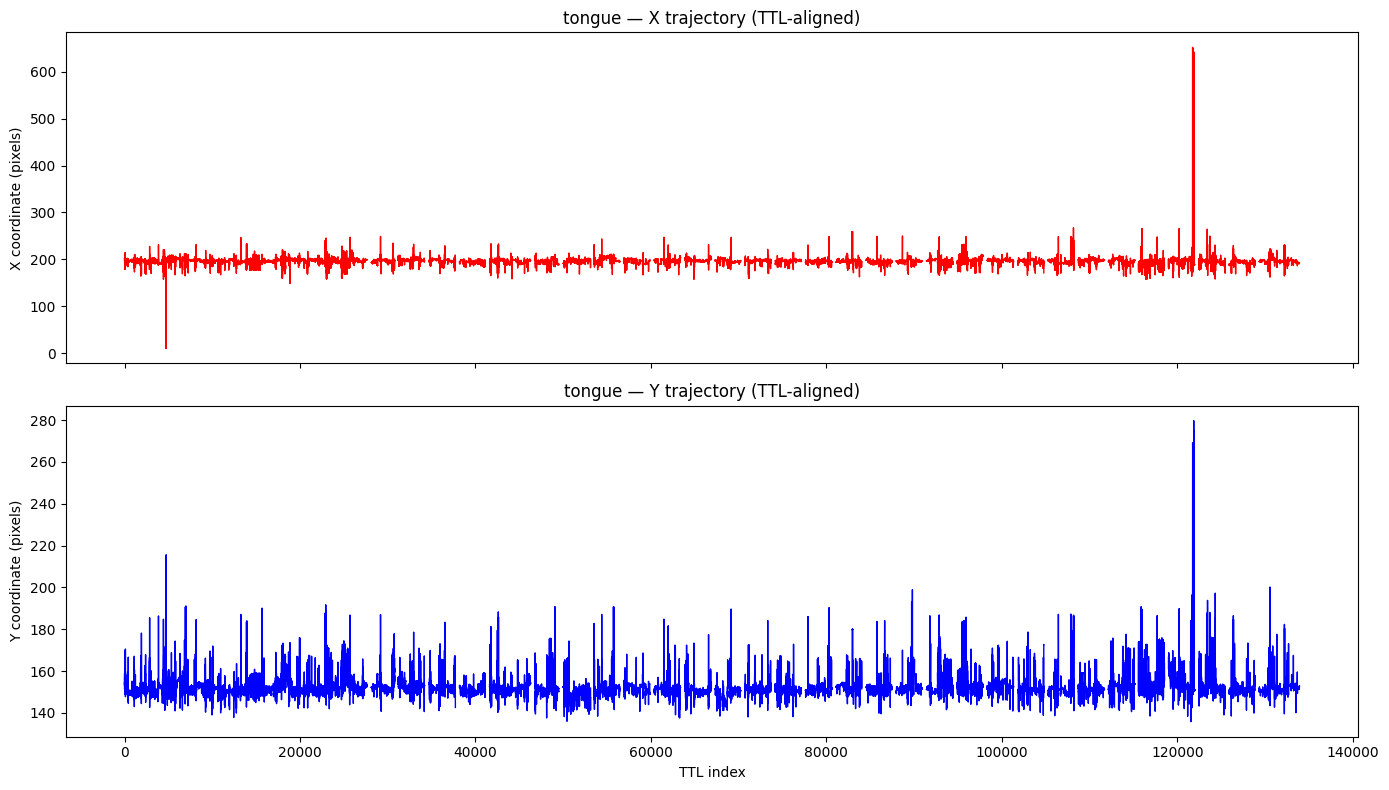

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ======================= USER INPUTS =========================
# ============================================================

# Path to dlc_aligned.npy
dlc_aligned_path = r"D:\Kevin\04032026\04032026-1\cam1\dlc_aligned.npy" ###########################################################################################################################

# Path to original DLC .h5 file (needed to get column structure)
dlc_h5_path = r"F:\Mouse1_030426-Kpk\videos\04032026-1_cam1DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100.h5"   ########################################################################

# Body part to plot (must match DLC labels)
bodypart = "tongue"   #################################################################################################################################################################################


# ============================================================
# ======================= LOAD DATA ===========================
# ============================================================

# Load DLC-aligned timeline (length = TTL_COUNT)
dlc_aligned = np.load(dlc_aligned_path, allow_pickle=True)

# Load original DLC dataframe to inspect column structure
df_dlc = pd.read_hdf(dlc_h5_path)

print("Loaded DLC-aligned timeline:", len(dlc_aligned))
print("Loaded DLC dataframe:", df_dlc.shape)


# ============================================================
# ========== EXTRACT BODY PART COLUMNS FROM DLC ==============
# ============================================================

# DLC uses a MultiIndex: (scorer, bodypart, coordinate)
# Example: ('DLC_resnet50', 'paw', 'x')

# Find all columns for this bodypart
cols = [col for col in df_dlc.columns if col[1] == bodypart]

if len(cols) == 0:
    raise ValueError(f"Bodypart '{bodypart}' not found in DLC file. Available: {set(c[1] for c in df_dlc.columns)}")

print("Columns for bodypart:", cols)

# Coordinates
x_col = [c for c in cols if c[2] == 'x'][0]
y_col = [c for c in cols if c[2] == 'y'][0]
lik_col = [c for c in cols if c[2] == 'likelihood'][0]


# ============================================================
# ========== BUILD TTL-ALIGNED X/Y TRAJECTORIES ==============
# ============================================================

x_aligned = []
y_aligned = []
lik_aligned = []

for row in dlc_aligned:
    if row is None:
        x_aligned.append(np.nan)
        y_aligned.append(np.nan)
        lik_aligned.append(np.nan)
    else:
        x_aligned.append(row[x_col])
        y_aligned.append(row[y_col])
        lik_aligned.append(row[lik_col])

x_aligned = np.array(x_aligned, dtype=float)
y_aligned = np.array(y_aligned, dtype=float)
lik_aligned = np.array(lik_aligned, dtype=float)


# ============================================================
# ======================= PLOT RESULTS ========================
# ============================================================

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(x_aligned, color='red', linewidth=1)
ax[0].set_ylabel("X coordinate (pixels)")
ax[0].set_title(f"{bodypart} — X trajectory (TTL-aligned)")

ax[1].plot(y_aligned, color='blue', linewidth=1)
ax[1].set_ylabel("Y coordinate (pixels)")
ax[1].set_xlabel("TTL index")
ax[1].set_title(f"{bodypart} — Y trajectory (TTL-aligned)")

plt.tight_layout()
plt.show()